# 1. Download e Tratamento dos Dados

## 1.1 Download do Dataset

In [20]:
import pandas as pd

# Download latest version
path = "bodyPerformance.csv"

print("Path to dataset files:", path)

Path to dataset files: bodyPerformance.csv


## 1.2 Carregamento e Exploração Inicial

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


<class 'pandas.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  str    
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  str    
dtypes: float64(10), str(2)
memory usage: 1.2 MB
None


,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000
mean,36.775106,168.559807,67.447316,23.240165,78.796842,130.234817,36.963877,15.209268,39.771224,190.129627
std,13.625639,8.426583,11.949666,7.256844,10.742033,14.713954,10.624864,8.456677,14.276698,39.868000
min,21.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


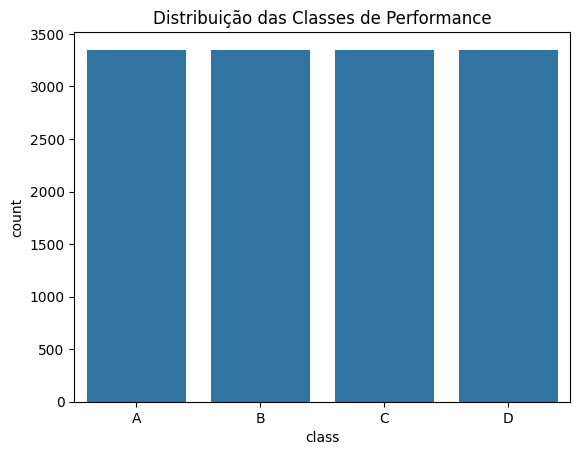

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(path)

display(df.head())
print(df.info())

display(df.describe())

sns.countplot(data=df, x='class', order=['A', 'B', 'C', 'D'])
plt.title('Distribuição das Classes de Performance')
plt.show()

In [22]:
# Contagem de indivíduos por classe
contagem_classes = df['class'].value_counts()
print(contagem_classes)

class
C    3349
D    3349
A    3348
B    3347
Name: count, dtype: int64


## 1.3 Análise Exploratória por Gênero e Classe

gender
M    8467
F    4926
Name: count, dtype: int64

Proporção de Gênero por Classe (%):


gender,F,M
class,,
A,44.32,55.68
B,35.40,64.60
C,33.20,66.80
D,34.19,65.81


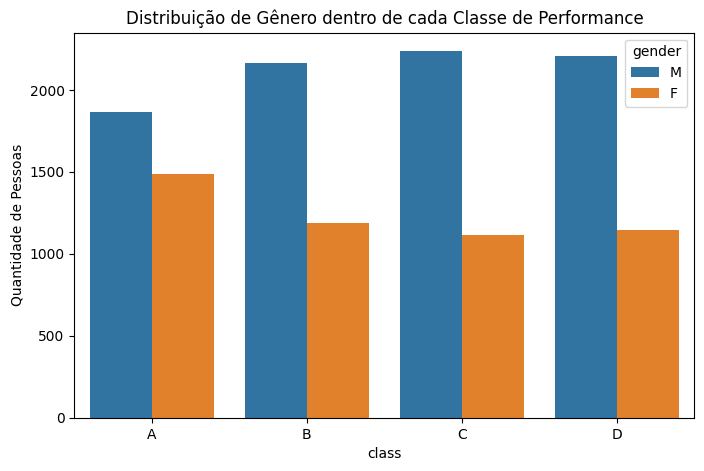

In [23]:
display(df['gender'].value_counts())

# Tabela cruzada mostrando a porcentagem de homens e mulheres dentro de cada classe
tendencia_genero = pd.crosstab(df['class'], df['gender'], normalize='index') * 100
print("Proporção de Gênero por Classe (%):")
display(tendencia_genero.round(2))

# Gráfico visual
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='class', hue='gender', order=['A', 'B', 'C', 'D'])
plt.title('Distribuição de Gênero dentro de cada Classe de Performance')
plt.ylabel('Quantidade de Pessoas')
plt.show()

In [24]:
# Agrupa pela classe e calcula a média apenas das colunas numéricas
medias_por_classe = df.groupby('class').mean(numeric_only=True)

print("Médias das medidas físicas para cada classe:")
display(medias_por_classe.round(2)) # round(2) deixa apenas 2 casas decimais para facilitar a leitura

Médias das medidas físicas para cada classe:


,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
class,,,,,,,,,,
A,35.27,167.87,64.42,20.54,77.90,129.29,38.62,21.39,47.85,202.74
B,37.07,168.58,66.61,22.04,78.66,130.64,37.91,17.47,42.64,195.33
C,36.70,169.16,66.76,22.64,78.55,129.93,36.58,14.39,38.72,188.63
D,38.06,168.63,72.00,27.74,80.08,131.08,34.75,7.59,29.88,173.82


# 2. Matriz de Correlação

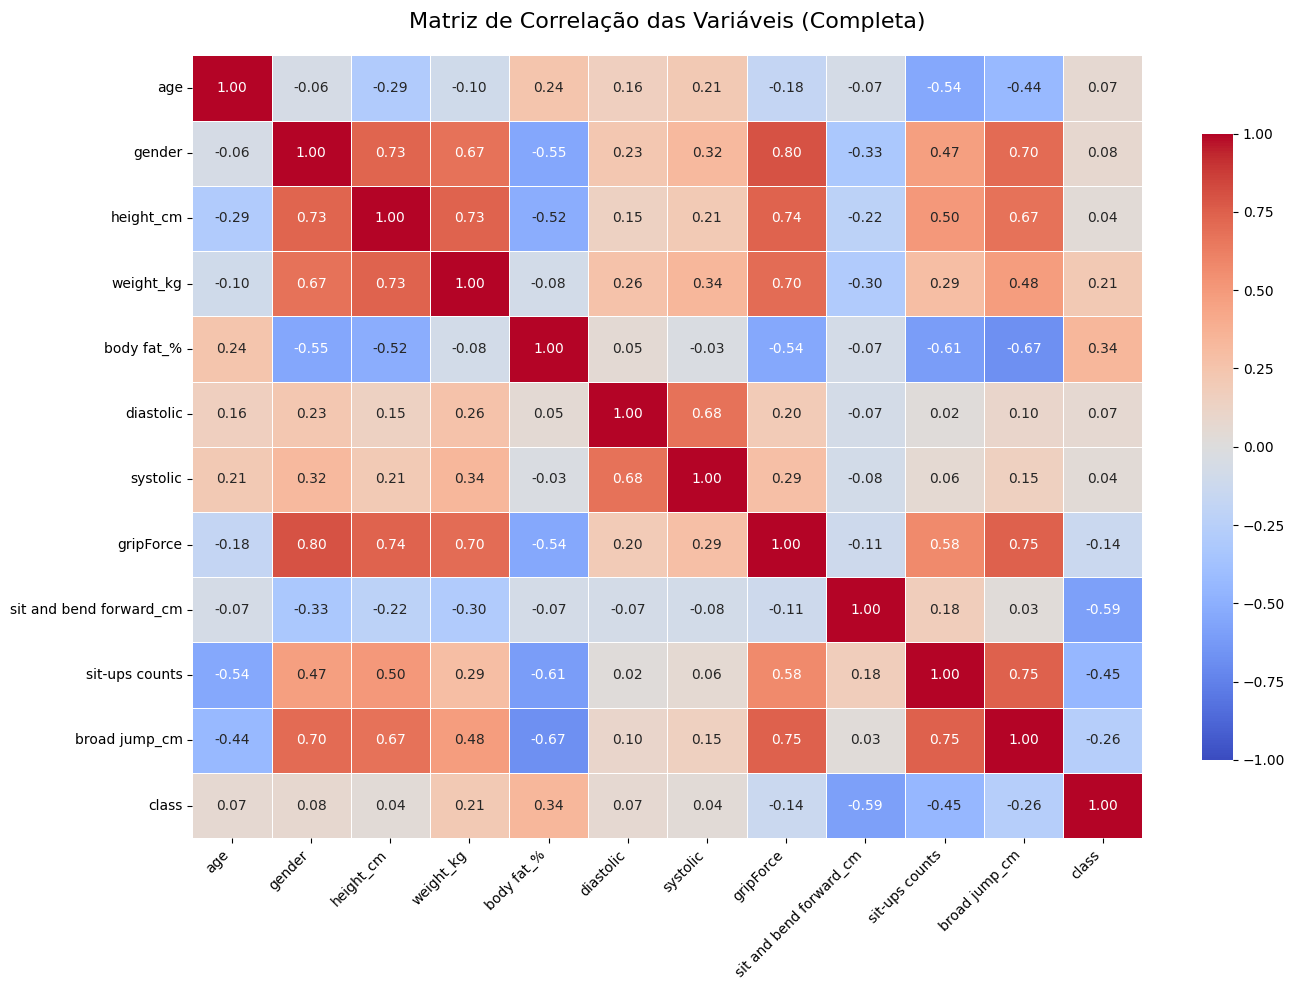

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')

# 1. Criar uma cópia limpa
df_corr = df.copy()

# 2. Transformar textos em números
encoder = LabelEncoder()
df_corr['gender'] = encoder.fit_transform(df_corr['gender'])
df_corr['class'] = encoder.fit_transform(df_corr['class'])

# 3. Calcular a matriz de correlação
matriz_correlacao = df_corr.corr()

# 4. Configurar o visual do gráfico (Heatmap COMPLETO)
plt.figure(figsize=(14, 10))

# Plotando o mapa de calor SEM a máscara
sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlação das Variáveis (Completa)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Modelos Supervisionados (sem PCA)

## 3.1 Regressão Logística

Mapeamento das classes: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3)}


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
13388,25.0,1,172.1,71.8,16.2,74.0,141.0,35.8,17.4,47.0,198.0,2
13389,21.0,1,179.7,63.9,12.1,74.0,128.0,33.0,1.1,48.0,167.0,3
13390,39.0,1,177.2,80.5,20.1,78.0,132.0,63.5,16.4,45.0,229.0,0
13391,64.0,0,146.1,57.7,40.4,68.0,121.0,19.3,9.2,0.0,75.0,3
13392,34.0,1,164.0,66.1,19.5,82.0,150.0,35.9,7.1,51.0,180.0,2



Resultados: Regressão Logística
Acurácia: 0.6275
Precisão: 0.6231
Recall:   0.6274
F1-score: 0.6246
ROC-AUC:  0.8567



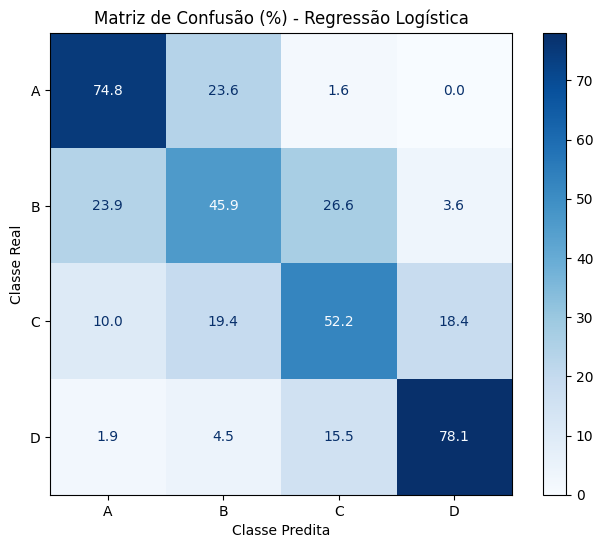

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

# 1. Copia do db
df_logreg = df.copy()

# 2. Transformando 'gender' (M/F) em (0/1)
encoder_gender = LabelEncoder()
df_logreg['gender'] = encoder_gender.fit_transform(df_logreg['gender'])

# 3. Transformando a variavel alvo - (A/B/C/D) -> (0/1/2/3)
encoder_class = LabelEncoder()
df_logreg['class'] = encoder_class.fit_transform(df_logreg['class'])

# Verificando como ficou o mapeamento das classes
print("Mapeamento das classes:", dict(zip(encoder_class.classes_, encoder_class.transform(encoder_class.classes_))))
display(df_logreg.tail(5))

# 4. X recebe todas as colunas, exceto a coluna 'class'
X = df_logreg.drop('class', axis=1)

# y recebe apenas a coluna 'class'
y = df_logreg['class']

# 5. Divisão de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Padronização
scaler = StandardScaler()
# O scaler "aprende" as médias e desvios apenas do X_train e já aplica a transformação
X_train_scaled = scaler.fit_transform(X_train)
# O scaler apenas aplica a régua que aprendeu no passo anterior aos dados de teste
X_test_scaled = scaler.transform(X_test)

# 7. Instanciando o modelo
# max_iter=1000 garante que o algoritmo tenha "passos" suficientes para achar o ponto mínimo
logreg_model = LogisticRegression(max_iter=1000, random_state=42)

# 8. Treinando o modelo (ajustando os pesos) com os dados de treino
logreg_model.fit(X_train_scaled, y_train)

# 9. Prevendo a classe final (A, B, C ou D codificadas)
y_pred = logreg_model.predict(X_test_scaled)

# Prevendo as probabilidades de cada amostra pertencer a cada classe (necessário para o AUC)
y_prob = logreg_model.predict_proba(X_test_scaled)

# 10. Calculando as métricas
acuracia = accuracy_score(y_test, y_pred)
precisao = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')

# Imprimindo os resultados no formato para a sua tabela final
print("\nResultados: Regressão Logística")
print(f"Acurácia: {acuracia:.4f}")
print(f"Precisão: {precisao:.4f}")
print(f"Recall:   {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}\n")

# 11. Matriz de confusão normalizada em porcentagem
cm = confusion_matrix(y_test, y_pred, normalize='true') * 100

# Plotando
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder_class.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='.1f')

plt.title('Matriz de Confusão (%) - Regressão Logística')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')

plt.show()

## 3.2 Árvore de Decisão

Dados preparados com sucesso para a Árvore de Decisão!
Tamanho do treino: 10714 linhas
Tamanho do teste: 2679 linhas


Resultados: Árvore de Decisão
Acurácia: 0.6973
Precisão: 0.7045
Recall:   0.6972
F1-score: 0.6969
ROC-AUC:  0.8573


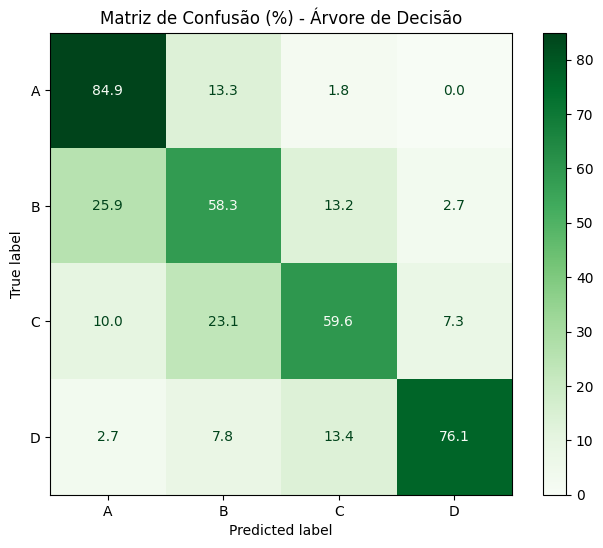

 O 'Cérebro' da Árvore de Decisão (Top 3 Níveis) 

|--- sit and bend forward_cm <= 9.25
|   |--- sit and bend forward_cm <= 4.55
|   |   |--- age <= 60.50
|   |   |   |--- age <= 55.50
|   |   |   |   |--- class: 3
|   |   |   |--- age >  55.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- age >  60.50
|   |   |   |--- sit and bend forward_cm <= 2.30
|   |   |   |   |--- class: 3
|   |   |   |--- sit and bend forward_cm >  2.30
|   |   |   |   |--- truncated branch of depth 5
|   |--- sit and bend forward_cm >  4.55
|   |   |--- body fat_% <= 25.05
|   |   |   |--- sit-ups counts <= 37.50
|   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- sit-ups counts >  37.50
|   |   |   |   |--- truncated branch of depth 8
|   |   |--- body fat_% >  25.05
|   |   |   |--- body fat_% <= 27.12
|   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- body fat_% >  27.12
|   |   |   |   |--- truncated branch of depth 8
|--- sit and bend forward_cm >  9.25
|   |--

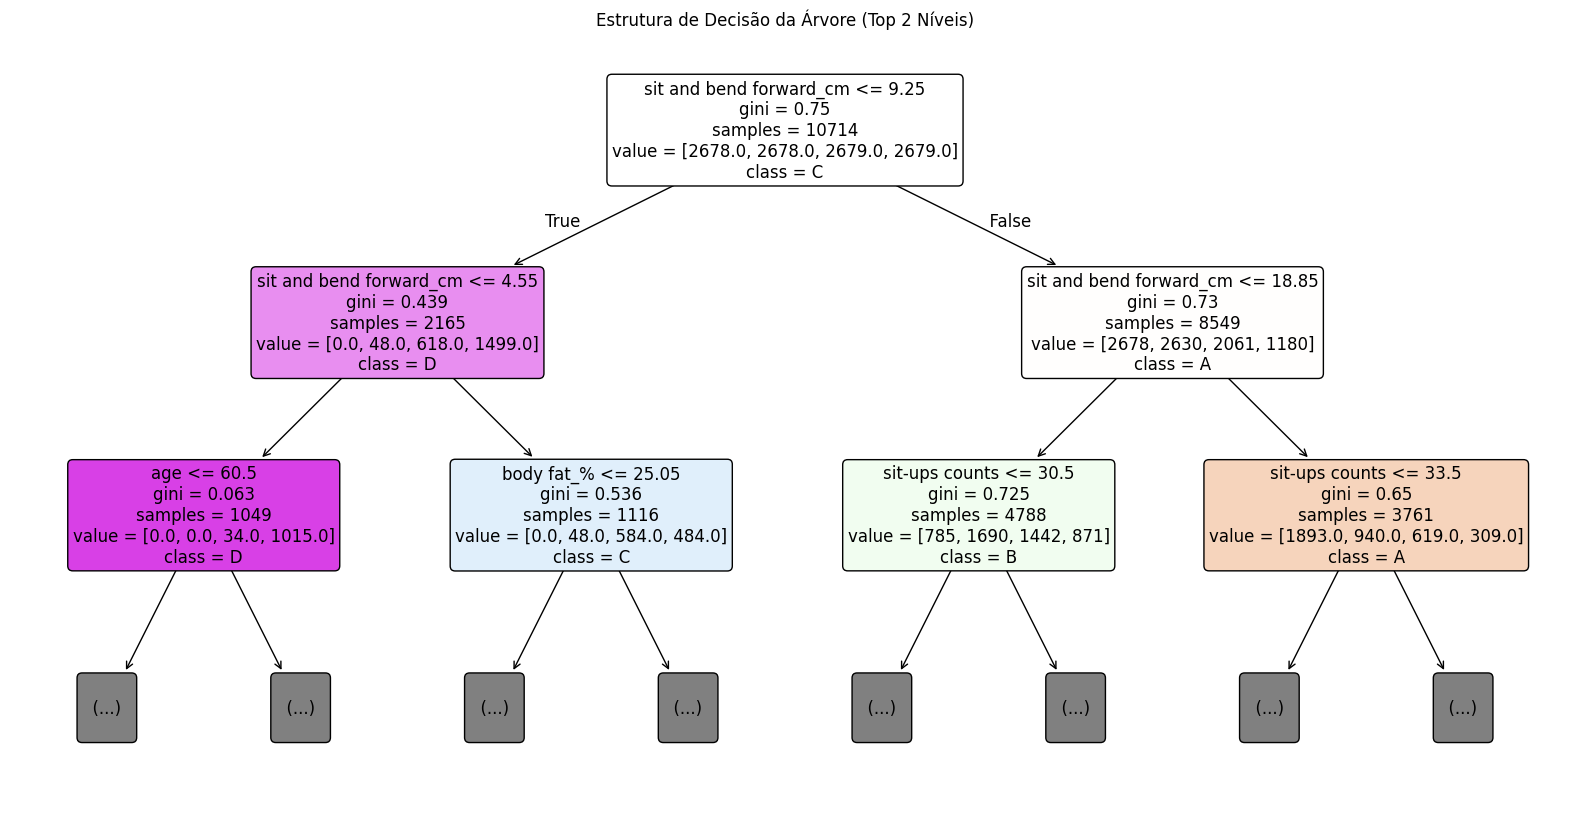

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Criando uma cópia totalmente limpa a partir do banco original
df_tree = df.copy()

# 2. Transformando textos em números (Encoding)
# Convertendo 'gender' (M/F) para (0/1)
encoder_gender_tree = LabelEncoder()
df_tree['gender'] = encoder_gender_tree.fit_transform(df_tree['gender'])

# Convertendo 'class' (A/B/C/D) para (0/1/2/3)
encoder_class_tree = LabelEncoder()
df_tree['class'] = encoder_class_tree.fit_transform(df_tree['class'])

# 3. Separando as Features (X) e o Target (y)
X_tree = df_tree.drop('class', axis=1)
y_tree = df_tree['class']

# 4. Divisão em Treino e Teste
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree, y_tree,
    test_size=0.2,
    random_state=42,
    stratify=y_tree # Garante a mesma proporção de A, B, C e D no treino e no teste
)

print("Dados preparados com sucesso para a Árvore de Decisão!")
print(f"Tamanho do treino: {X_train_tree.shape[0]} linhas")
print(f"Tamanho do teste: {X_test_tree.shape[0]} linhas")

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# 1. Instanciando o modelo com um limite de profundidade (Poda/Pruning)
tree_model = DecisionTreeClassifier(max_depth=11, random_state=42)

# 2. Treinando o modelo (Onde ele calcula o Gini e escolhe as melhores perguntas)
tree_model.fit(X_train_tree, y_train_tree)

# 3. Fazendo as previsões no conjunto de teste
y_pred_tree = tree_model.predict(X_test_tree)
y_prob_tree = tree_model.predict_proba(X_test_tree)

# 4. Calculando as métricas obrigatórias
acuracia_tree = accuracy_score(y_test_tree, y_pred_tree)
precisao_tree = precision_score(y_test_tree, y_pred_tree, average='macro')
recall_tree = recall_score(y_test_tree, y_pred_tree, average='macro')
f1_tree = f1_score(y_test_tree, y_pred_tree, average='macro')
roc_auc_tree = roc_auc_score(y_test_tree, y_prob_tree, multi_class='ovr')

# Imprimindo os resultados
print("\n")
print("Resultados: Árvore de Decisão")
print(f"Acurácia: {acuracia_tree:.4f}")
print(f"Precisão: {precisao_tree:.4f}")
print(f"Recall:   {recall_tree:.4f}")
print(f"F1-score: {f1_tree:.4f}")
print(f"ROC-AUC:  {roc_auc_tree:.4f}")

# 5. Plotando a Matriz de Confusão
cm_tree = confusion_matrix(y_test_tree, y_pred_tree, normalize='true') * 100
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=encoder_class_tree.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp_tree.plot(cmap='Greens', ax=ax, values_format='.1f') # Usando verde para diferenciar da LogReg
plt.title('Matriz de Confusão (%) - Árvore de Decisão')
plt.show()

from sklearn.tree import export_text, plot_tree

# Vamos exportar as regras em texto, limitando a visualização aos 3 primeiros níveis
regras_texto = export_text(tree_model, feature_names=list(X_train_tree.columns), max_depth=3)

print(" O 'Cérebro' da Árvore de Decisão (Top 3 Níveis) \n")
print(regras_texto)
print("-" * 50)

plt.figure(figsize=(20, 10))

# Desenhamos apenas o topo da árvore (max_depth=2) para que as caixas fiquem legíveis
plot_tree(tree_model,
          feature_names=list(X_train_tree.columns),  # Nome das colunas (Idade, Peso, etc)
          class_names=list(encoder_class_tree.classes_), # Nome das classes (A, B, C, D)
          filled=True,     # Pinta as caixinhas com a cor da classe dominante
          rounded=True,    # Arredonda as bordas
          fontsize=12,     # Tamanho da fonte
          max_depth=2)     # Mostra apenas as 2 primeiras perguntas

plt.title('Estrutura de Decisão da Árvore (Top 2 Níveis)')
plt.show()

## 3.3 Random Forest

✅ Dados preparados com sucesso para o Random Forest!
Tamanho do treino: 10714 linhas
Tamanho do teste: 2679 linhas


Resultados: Random Forest
Acurácia: 0.7529
Precisão: 0.7559
Recall:   0.7528
F1-score: 0.7519
ROC-AUC:  0.9201


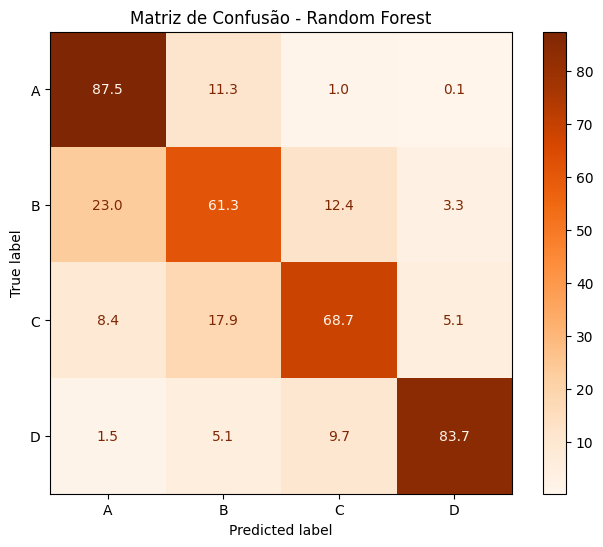

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Criando uma cópia exclusiva para o modelo Random Forest
df_rf = df.copy()

# 2. Codificação (Encoding) de Variáveis Categóricas
# Convertendo 'gender' de (M/F) para (0/1)
encoder_gender_rf = LabelEncoder()
df_rf['gender'] = encoder_gender_rf.fit_transform(df_rf['gender'])

# Convertendo 'class' de (A/B/C/D) para (0/1/2/3)
encoder_class_rf = LabelEncoder()
df_rf['class'] = encoder_class_rf.fit_transform(df_rf['class'])

# 3. Separação entre Features (X) e Target (y)
X_rf = df_rf.drop('class', axis=1)
y_rf = df_rf['class']

# 4. Divisão em Treino e Teste
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf,
    test_size=0.2,
    random_state=42,
    stratify=y_rf # Mantém a mesma proporção de cada classe nos dois conjuntos
)

print("✅ Dados preparados com sucesso para o Random Forest!")
print(f"Tamanho do treino: {X_train_rf.shape[0]} linhas")
print(f"Tamanho do teste: {X_test_rf.shape[0]} linhas")

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# 1. Instanciando o modelo (A Floresta)
# n_estimators=100 (100 árvores no conselho)
# max_depth=10 (cada árvore pode fazer até 10 perguntas)
rf_model = RandomForestClassifier(n_estimators=130, max_depth=25, random_state=42)

# 2. Treinamento (onde o sorteio de colunas e linhas acontece por debaixo dos panos)
rf_model.fit(X_train_rf, y_train_rf)

# 3. Fazendo as previsões no conjunto de teste
y_pred_rf = rf_model.predict(X_test_rf)
y_prob_rf = rf_model.predict_proba(X_test_rf)

# 4. Calculando as métricas obrigatórias
acuracia_rf = accuracy_score(y_test_rf, y_pred_rf)
precisao_rf = precision_score(y_test_rf, y_pred_rf, average='macro')
recall_rf = recall_score(y_test_rf, y_pred_rf, average='macro')
f1_rf = f1_score(y_test_rf, y_pred_rf, average='macro')
roc_auc_rf = roc_auc_score(y_test_rf, y_prob_rf, multi_class='ovr')

# Imprimindo os resultados
print("\n")
print("Resultados: Random Forest")
print(f"Acurácia: {acuracia_rf:.4f}")
print(f"Precisão: {precisao_rf:.4f}")
print(f"Recall:   {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print(f"ROC-AUC:  {roc_auc_rf:.4f}")

# 5. Plotando a Matriz de Confusão
cm_rf = confusion_matrix(y_test_rf, y_pred_rf, normalize='true') * 100
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=encoder_class_rf.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp_rf.plot(cmap='Oranges', ax=ax, values_format='.1f') # Laranja para diferenciar
plt.title('Matriz de Confusão - Random Forest')
plt.show()

## 3.4 XGBoost

Resultados: XGBoost
Acurácia: 0.7630
Precisão: 0.7699
Recall:   0.7629
F1-score: 0.7625
ROC-AUC:  0.9281


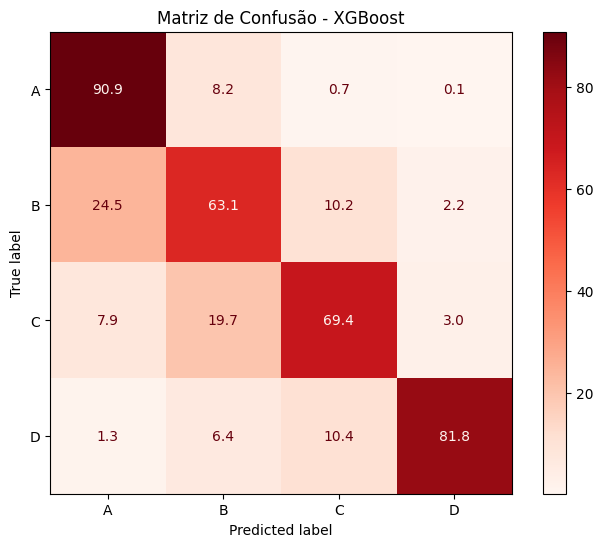

In [29]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# 1. Preparando os dados (Cópia isolada)
df_xgb = df.copy()

# Transformando 'gender' (M/F) para (0/1)
encoder_gender_xgb = LabelEncoder()
df_xgb['gender'] = encoder_gender_xgb.fit_transform(df_xgb['gender'])

# Transformando 'class' (A/B/C/D) para (0/1/2/3)
encoder_class_xgb = LabelEncoder()
df_xgb['class'] = encoder_class_xgb.fit_transform(df_xgb['class'])

# Separando X e y
X_xgb = df_xgb.drop('class', axis=1)
y_xgb = df_xgb['class']

# Dividindo em Treino e Teste
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb,
    test_size=0.2,
    random_state=42,
    stratify=y_xgb
)

# 2. Instanciando o modelo XGBoost
# learning_rate=0.1: Define o tamanho do "passo" que cada nova árvore dá para corrigir o erro.
# objective='multi:softprob': Instrui o XGBoost a usar a função Softmax para múltiplas classes.
xgb_model = xgb.XGBClassifier( n_estimators=110, max_depth=8, learning_rate=0.1, objective='multi:softprob', random_state=42)

# 3. Treinando o modelo
xgb_model.fit(X_train_xgb, y_train_xgb)

# 4. Fazendo as previsões
y_pred_xgb = xgb_model.predict(X_test_xgb)
y_prob_xgb = xgb_model.predict_proba(X_test_xgb)

# 5. Calculando as métricas obrigatórias
acuracia_xgb = accuracy_score(y_test_xgb, y_pred_xgb)
precisao_xgb = precision_score(y_test_xgb, y_pred_xgb, average='macro')
recall_xgb = recall_score(y_test_xgb, y_pred_xgb, average='macro')
f1_xgb = f1_score(y_test_xgb, y_pred_xgb, average='macro')
roc_auc_xgb = roc_auc_score(y_test_xgb, y_prob_xgb, multi_class='ovr')

# Imprimindo os resultados para a sua tabela
print("Resultados: XGBoost")
print(f"Acurácia: {acuracia_xgb:.4f}")
print(f"Precisão: {precisao_xgb:.4f}")
print(f"Recall:   {recall_xgb:.4f}")
print(f"F1-score: {f1_xgb:.4f}")
print(f"ROC-AUC:  {roc_auc_xgb:.4f}")

# 6. Plotando a Matriz de Confusão
cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb, normalize = 'true')*100
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=encoder_class_xgb.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp_xgb.plot(cmap='Reds', ax=ax, values_format='.1f') # Vermelho para o XGBoost
plt.title('Matriz de Confusão - XGBoost')
plt.show()

## 3.5 SVM (SVC)

Resultados: SVM (SVC)
Acurácia: 0.6999
Precisão: 0.7077
Recall:   0.6998
F1-score: 0.7009
ROC-AUC:  0.8975


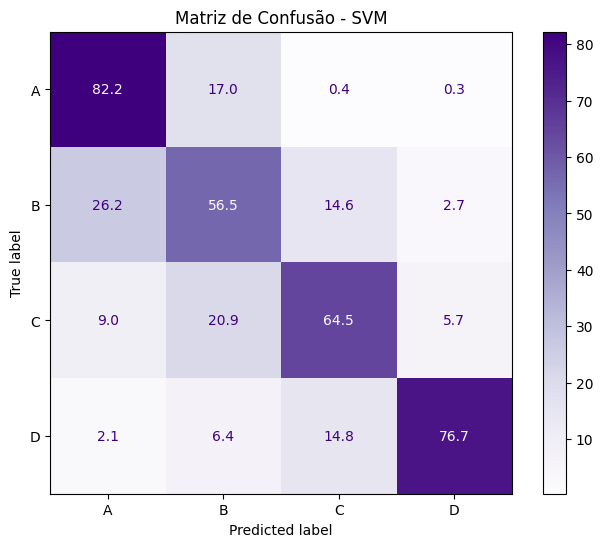

In [30]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# 1. Preparando os dados (Cópia isolada)
df_svm = df.copy()

# Transformando textos em números
encoder_gender_svm = LabelEncoder()
df_svm['gender'] = encoder_gender_svm.fit_transform(df_svm['gender'])

encoder_class_svm = LabelEncoder()
df_svm['class'] = encoder_class_svm.fit_transform(df_svm['class'])

# Separando X e y
X_svm = df_svm.drop('class', axis=1)
y_svm = df_svm['class']

# Dividindo em Treino e Teste
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y_svm,
    test_size=0.2,
    random_state=42,
    stratify=y_svm
)

# 2. O RETORNO DO ESCALONAMENTO (Essencial para o SVM)
scaler_svm = StandardScaler()
X_train_svm_scaled = scaler_svm.fit_transform(X_train_svm)
X_test_svm_scaled = scaler_svm.transform(X_test_svm)

# 3. Instanciando o modelo SVC
# kernel='rbf': Usa a mágica de jogar os dados para 3D para criar curvas.
# probability=True: Obrigatório para conseguirmos calcular o ROC-AUC depois.
# C=1.0: Valor padrão de regularização (tamanho da avenida).
svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)

# 4. Treinando o modelo
svm_model.fit(X_train_svm_scaled, y_train_svm)

# 5. Fazendo as previsões
y_pred_svm = svm_model.predict(X_test_svm_scaled)
y_prob_svm = svm_model.predict_proba(X_test_svm_scaled)

# 6. Calculando as métricas obrigatórias
acuracia_svm = accuracy_score(y_test_svm, y_pred_svm)
precisao_svm = precision_score(y_test_svm, y_pred_svm, average='macro')
recall_svm = recall_score(y_test_svm, y_pred_svm, average='macro')
f1_svm = f1_score(y_test_svm, y_pred_svm, average='macro')
roc_auc_svm = roc_auc_score(y_test_svm, y_prob_svm, multi_class='ovr')

# Imprimindo os resultados para a sua tabela
print("Resultados: SVM (SVC)")
print(f"Acurácia: {acuracia_svm:.4f}")
print(f"Precisão: {precisao_svm:.4f}")
print(f"Recall:   {recall_svm:.4f}")
print(f"F1-score: {f1_svm:.4f}")
print(f"ROC-AUC:  {roc_auc_svm:.4f}")

# 7. Plotando a Matriz de Confusão
cm_svm = confusion_matrix(y_test_svm, y_pred_svm, normalize = 'true')*100
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=encoder_class_svm.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp_svm.plot(cmap='Purples', ax=ax, values_format='.1f') # Roxo para o SVM
plt.title('Matriz de Confusão - SVM')
plt.show()

## 3.6 Rede Neural (MLP)

Resultados: Rede Neural (MLP)
Acurácia: 0.7484
Precisão: 0.7580
Recall:   0.7484
F1-score: 0.7479
ROC-AUC:  0.9184


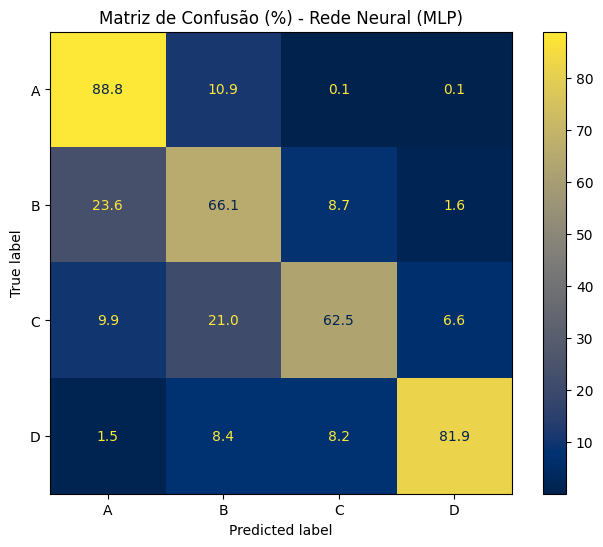

In [31]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# 1. Preparando os dados (Cópia isolada)
df_mlp = df.copy()

# Transformando textos em números
encoder_gender_mlp = LabelEncoder()
df_mlp['gender'] = encoder_gender_mlp.fit_transform(df_mlp['gender'])

encoder_class_mlp = LabelEncoder()
df_mlp['class'] = encoder_class_mlp.fit_transform(df_mlp['class'])

# Separando X e y
X_mlp = df_mlp.drop('class', axis=1)
y_mlp = df_mlp['class']

# Dividindo em Treino e Teste
X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(
    X_mlp, y_mlp,
    test_size=0.2,
    random_state=42,
    stratify=y_mlp
)

# 2. OBRIGATÓRIO: Escalonamento dos dados para a Rede Neural
scaler_mlp = StandardScaler()
X_train_mlp_scaled = scaler_mlp.fit_transform(X_train_mlp)
X_test_mlp_scaled = scaler_mlp.transform(X_test_mlp)

# 3. Instanciando o modelo MLP (Rede Neural)
# hidden_layer_sizes=(20, 10): 2 camadas ocultas, uma com 20 e outra com 10 neurônios.
# max_iter=50: Permite que a rede faça até 50 épocas (idas e voltas) para aprender.
mlp_model = MLPClassifier(hidden_layer_sizes=(20, 10), max_iter=50, random_state=42)

# 4. Treinando o modelo (Isso pode levar alguns segundos dependendo do computador)
mlp_model.fit(X_train_mlp_scaled, y_train_mlp)

# 5. Fazendo as previsões
y_pred_mlp = mlp_model.predict(X_test_mlp_scaled)
y_prob_mlp = mlp_model.predict_proba(X_test_mlp_scaled)

# 6. Calculando as métricas obrigatórias
acuracia_mlp = accuracy_score(y_test_mlp, y_pred_mlp)
precisao_mlp = precision_score(y_test_mlp, y_pred_mlp, average='macro')
recall_mlp = recall_score(y_test_mlp, y_pred_mlp, average='macro')
f1_mlp = f1_score(y_test_mlp, y_pred_mlp, average='macro')
roc_auc_mlp = roc_auc_score(y_test_mlp, y_prob_mlp, multi_class='ovr')

# Imprimindo os resultados para a sua tabela
print("Resultados: Rede Neural (MLP)")
print(f"Acurácia: {acuracia_mlp:.4f}")
print(f"Precisão: {precisao_mlp:.4f}")
print(f"Recall:   {recall_mlp:.4f}")
print(f"F1-score: {f1_mlp:.4f}")
print(f"ROC-AUC:  {roc_auc_mlp:.4f}")

# 7. Plotando a Matriz de Confusão em Porcentagem
cm_mlp = confusion_matrix(y_test_mlp, y_pred_mlp, normalize='true') * 100
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=encoder_class_mlp.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
# values_format='.1f' garante que o número apareça como porcentagem com 1 casa decimal
disp_mlp.plot(cmap='cividis', ax=ax, values_format='.1f')
plt.title('Matriz de Confusão (%) - Rede Neural (MLP)')
plt.show()

# 4. Modelos Supervisionados com PCA

## 4.1 Redução de Dimensionalidade (PCA 2D)

Resultados: PCA
Variância explicada pelo PC1: 44.47%
Variância explicada pelo PC2: 19.11%
Variância Total Retida no mapa 2D: 63.58%


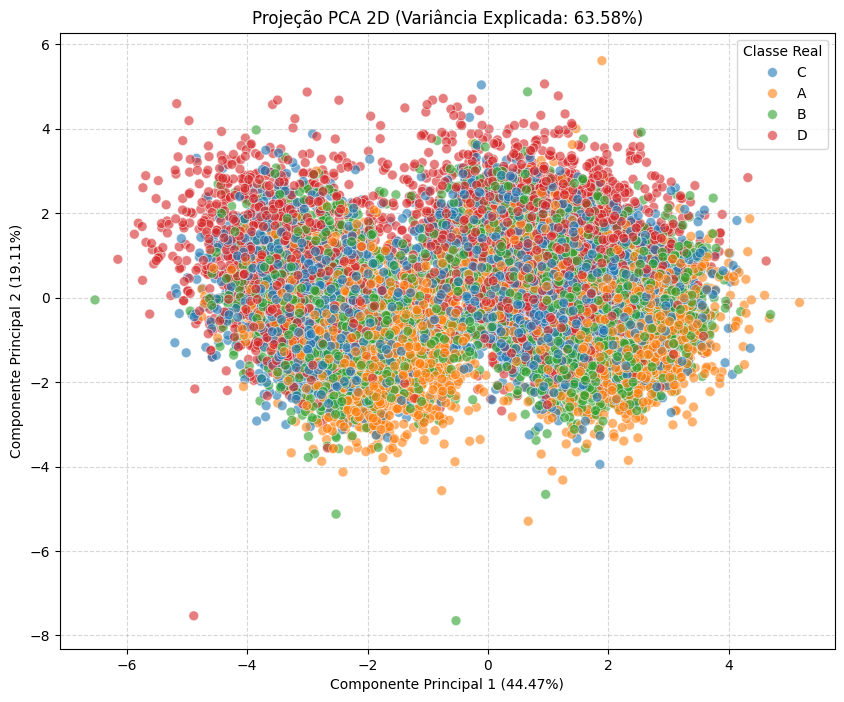

In [32]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparando os dados (Usaremos as Features Numéricas e a Classe apenas para colorir)
# Como o PCA é não supervisionado, nós "escondemos" a variável 'class' do algoritmo.
X_pca_raw = df.drop('class', axis=1)

# Como já temos a coluna 'gender' como M/F no dataframe original (df),
# precisamos codificá-la para 0/1 só para essa matriz.
X_pca = X_pca_raw.copy()
X_pca['gender'] = LabelEncoder().fit_transform(X_pca['gender'])

# 2. ESCALONAMENTO OBRIGATÓRIO
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca)

# 3. Aplicando o PCA (Reduzindo 11 colunas para apenas 2)
# n_components=2: Queremos um mapa 2D clássico
pca = PCA(n_components=2, random_state=42)
componentes_principais = pca.fit_transform(X_pca_scaled)

# Criando um novo DataFrame com as duas novas colunas (PC1 e PC2) e a classe real para o gráfico
df_pca = pd.DataFrame(data=componentes_principais, columns=['PC1', 'PC2'])
df_pca['Classe Real'] = df['class']

# 4. Extraindo a Variância Explicada (Métrica exigida pelo professor)
variancia = pca.explained_variance_ratio_
variancia_total_2d = variancia.sum() * 100

print("Resultados: PCA")
print(f"Variância explicada pelo PC1: {variancia[0]*100:.2f}%")
print(f"Variância explicada pelo PC2: {variancia[1]*100:.2f}%")
print(f"Variância Total Retida no mapa 2D: {variancia_total_2d:.2f}%")

# 5. Visualização 2D (Scatter Plot)
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Classe Real',
    data=df_pca,
    palette=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], # Cores distintas para A,B,C,D
    alpha=0.6, # Transparência para ver sobreposições
    s=50 # Tamanho das bolinhas
)
plt.title(f'Projeção PCA 2D (Variância Explicada: {variancia_total_2d:.2f}%)')
plt.xlabel(f'Componente Principal 1 ({variancia[0]*100:.2f}%)')
plt.ylabel(f'Componente Principal 2 ({variancia[1]*100:.2f}%)')
plt.legend(title='Classe Real')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4.2 Regressão Logística com PCA

Resultados: Regressão Logística com PCA (2D)
Acurácia: 0.3811
Precisão: 0.3424
Recall:   0.3810
F1-score: 0.3387
ROC-AUC:  0.6498
----------------------------------------------------


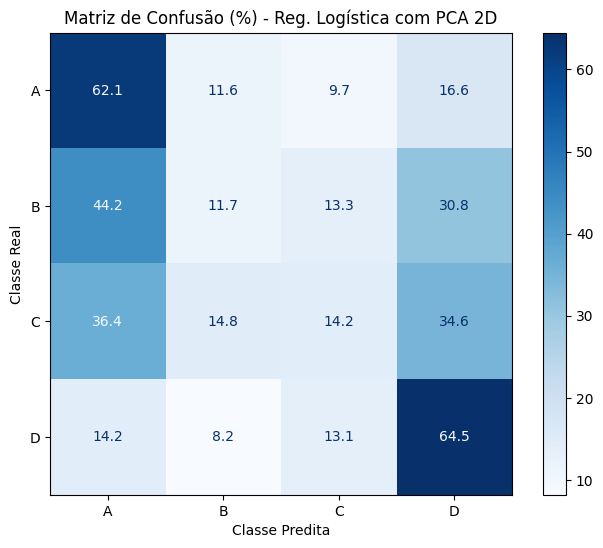

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

# Suprimindo avisos do Sklearn para manter a tela limpa
warnings.filterwarnings('ignore')

# 1. Preparando X e y a partir do df_pca (Usando apenas PC1 e PC2)
X_pca_logreg = df_pca[['PC1', 'PC2']]
y_pca_logreg = df_pca['Classe Real']

# 2. Transformando a variável alvo (A/B/C/D) -> (0/1/2/3)
encoder_class_pca = LabelEncoder()
y_encoded_pca = encoder_class_pca.fit_transform(y_pca_logreg)

# 3. Dividindo em Treino e Teste
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_logreg, y_encoded_pca, test_size=0.2, random_state=42, stratify=y_encoded_pca
)

# 4. Escalonamento
# Embora o PCA já seja uma projeção escalonada, passar o StandardScaler garante
# que a Regressão Logística receba os dados perfeitamente centralizados.
scaler_pca_logreg = StandardScaler()
X_train_scaled_pca = scaler_pca_logreg.fit_transform(X_train_pca)
X_test_scaled_pca = scaler_pca_logreg.transform(X_test_pca)

# 5. Instanciando e Treinando o Modelo
logreg_pca_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_pca_model.fit(X_train_scaled_pca, y_train_pca)

# 6. Prevendo classes e probabilidades
y_pred_pca = logreg_pca_model.predict(X_test_scaled_pca)
y_prob_pca = logreg_pca_model.predict_proba(X_test_scaled_pca)

# 7. Calculando todas as Métricas
acuracia_pca = accuracy_score(y_test_pca, y_pred_pca)
precisao_pca = precision_score(y_test_pca, y_pred_pca, average='macro')
recall_pca = recall_score(y_test_pca, y_pred_pca, average='macro')
f1_pca = f1_score(y_test_pca, y_pred_pca, average='macro')
roc_auc_pca = roc_auc_score(y_test_pca, y_prob_pca, multi_class='ovr')

# Imprimindo os resultados formatados
print("Resultados: Regressão Logística com PCA (2D)")
print(f"Acurácia: {acuracia_pca:.4f}")
print(f"Precisão: {precisao_pca:.4f}")
print(f"Recall:   {recall_pca:.4f}")
print(f"F1-score: {f1_pca:.4f}")
print(f"ROC-AUC:  {roc_auc_pca:.4f}")
print("-" * 52)

# 8. Matriz de Confusão em Porcentagem
# normalize='true' calcula a % em relação ao total de cada linha (Classe Real)
cm_percent_pca = confusion_matrix(y_test_pca, y_pred_pca, normalize='true') * 100

# Plotando a Matriz
disp_pca = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent_pca,
    display_labels=encoder_class_pca.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
# values_format='.1f' garante que o número apareça como "45.2" em vez de notação científica
disp_pca.plot(cmap='Blues', ax=ax, values_format='.1f')

plt.title('Matriz de Confusão (%) - Reg. Logística com PCA 2D')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.show()

Resultados: Regressão Logística com PCA (2D)
Acurácia: 0.3811
Precisão: 0.3424
Recall:   0.3810
F1-score: 0.3387
ROC-AUC:  0.6498
----------------------------------------------------


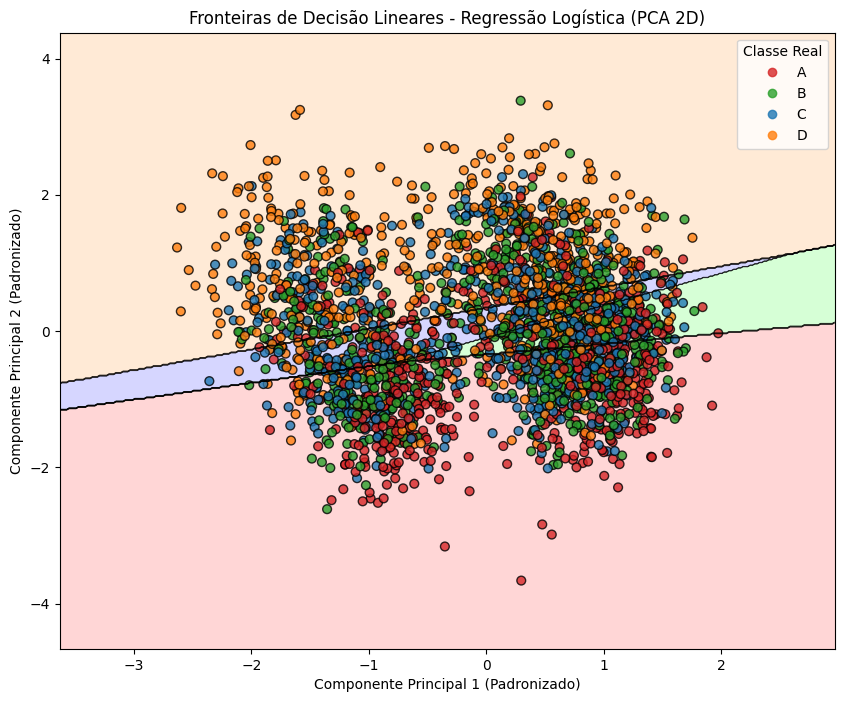

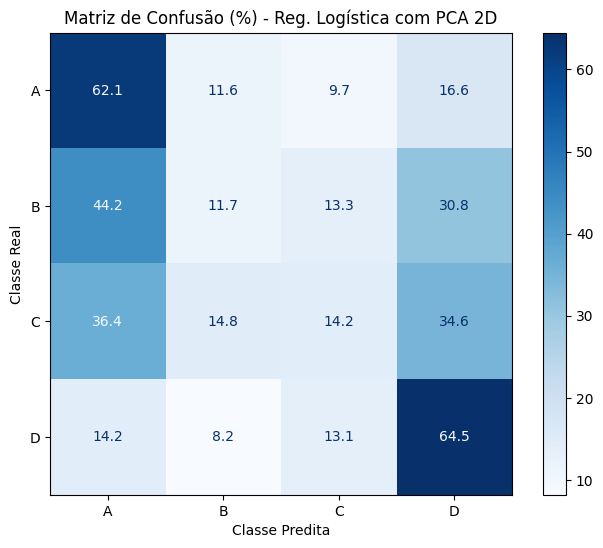

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from matplotlib.colors import ListedColormap

# Suprimindo avisos do Sklearn para manter a tela limpa
warnings.filterwarnings('ignore')

# 1. Preparando X e y a partir do df_pca (Usando apenas PC1 e PC2)
X_pca_logreg = df_pca[['PC1', 'PC2']]
y_pca_logreg = df_pca['Classe Real']

# 2. Transformando a variável alvo (A/B/C/D) -> (0/1/2/3)
encoder_class_pca = LabelEncoder()
y_encoded_pca = encoder_class_pca.fit_transform(y_pca_logreg)

# 3. Dividindo em Treino e Teste
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_logreg, y_encoded_pca, test_size=0.2, random_state=42, stratify=y_encoded_pca
)

# 4. Escalonamento
scaler_pca_logreg = StandardScaler()
X_train_scaled_pca = scaler_pca_logreg.fit_transform(X_train_pca)
X_test_scaled_pca = scaler_pca_logreg.transform(X_test_pca)

# 5. Instanciando e Treinando o Modelo
logreg_pca_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_pca_model.fit(X_train_scaled_pca, y_train_pca)

# 6. Prevendo classes e probabilidades
y_pred_pca = logreg_pca_model.predict(X_test_scaled_pca)
y_prob_pca = logreg_pca_model.predict_proba(X_test_scaled_pca)

# 7. Calculando todas as Métricas
acuracia_pca = accuracy_score(y_test_pca, y_pred_pca)
precisao_pca = precision_score(y_test_pca, y_pred_pca, average='macro')
recall_pca = recall_score(y_test_pca, y_pred_pca, average='macro')
f1_pca = f1_score(y_test_pca, y_pred_pca, average='macro')
roc_auc_pca = roc_auc_score(y_test_pca, y_prob_pca, multi_class='ovr')

print("Resultados: Regressão Logística com PCA (2D)")
print(f"Acurácia: {acuracia_pca:.4f}")
print(f"Precisão: {precisao_pca:.4f}")
print(f"Recall:   {recall_pca:.4f}")
print(f"F1-score: {f1_pca:.4f}")
print(f"ROC-AUC:  {roc_auc_pca:.4f}")
print("-" * 52)

# =====================================================================
# NOVO BLOCO: PLOTANDO AS FRONTEIRAS DE DECISÃO (AS "RETAS")
# =====================================================================
plt.figure(figsize=(10, 8))

# Criando uma malha de pontos (grid) para cobrir o gráfico inteiro
x_min, x_max = X_test_scaled_pca[:, 0].min() - 1, X_test_scaled_pca[:, 0].max() + 1
y_min, y_max = X_test_scaled_pca[:, 1].min() - 1, X_test_scaled_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Prevendo a classe para cada ponto na malha para desenhar as regiões
Z = logreg_pca_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Desenhando o fundo colorido (as zonas de cada classe)
cmap_light = ListedColormap(['#FFCCCC', '#CCFFCC', '#CCCCFF', '#FFE5CC'])
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

# Desenhando as linhas exatas de separação
plt.contour(xx, yy, Z, colors='k', linewidths=0.5)

# Adicionando os pontos reais do conjunto de teste por cima
scatter = plt.scatter(X_test_scaled_pca[:, 0], X_test_scaled_pca[:, 1],
                      c=y_test_pca, cmap=ListedColormap(['#d62728', '#2ca02c', '#1f77b4', '#ff7f0e']),
                      edgecolor='k', s=40, alpha=0.8)

plt.title('Fronteiras de Decisão Lineares - Regressão Logística (PCA 2D)')
plt.xlabel('Componente Principal 1 (Padronizado)')
plt.ylabel('Componente Principal 2 (Padronizado)')

# Legenda baseada nas classes originais
classes_nomes = encoder_class_pca.classes_
plt.legend(handles=scatter.legend_elements()[0], labels=list(classes_nomes), title="Classe Real")
plt.show()

# =====================================================================
# 8. Matriz de Confusão em Porcentagem
# =====================================================================
cm_percent_pca = confusion_matrix(y_test_pca, y_pred_pca, normalize='true') * 100

disp_pca = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent_pca,
    display_labels=encoder_class_pca.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp_pca.plot(cmap='Blues', ax=ax, values_format='.1f')

plt.title('Matriz de Confusão (%) - Reg. Logística com PCA 2D')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.show()

## 4.3 Árvore de Decisão com PCA

Resultados: Árvore de Decisão com PCA (2D)
Acurácia: 0.3916
Precisão: 0.3799
Recall:   0.3915
F1-score: 0.3808
ROC-AUC:  0.6409


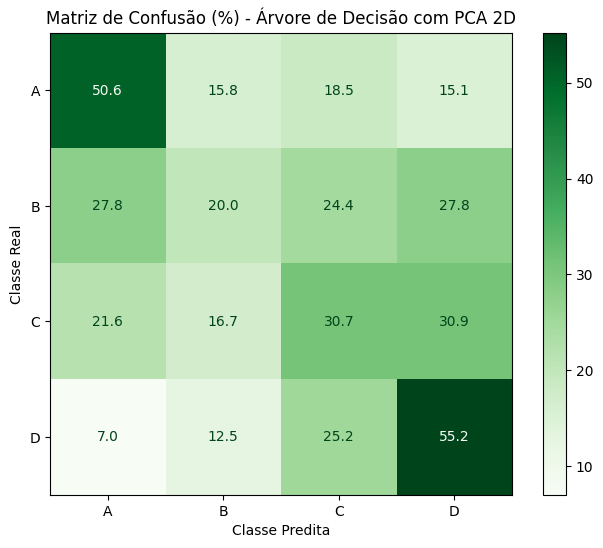

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

# Suprimindo avisos do Sklearn
warnings.filterwarnings('ignore')

# 1. Preparando X e y a partir do df_pca (Usando apenas PC1 e PC2)
X_pca_tree = df_pca[['PC1', 'PC2']]
y_pca_tree = df_pca['Classe Real']

# 2. Transformando a variável alvo (A/B/C/D) -> (0/1/2/3)
encoder_class_pca_tree = LabelEncoder()
y_encoded_pca_tree = encoder_class_pca_tree.fit_transform(y_pca_tree)

# 3. Dividindo em Treino e Teste
X_train_pca_tree, X_test_pca_tree, y_train_pca_tree, y_test_pca_tree = train_test_split(
    X_pca_tree, y_encoded_pca_tree, test_size=0.2, random_state=42, stratify=y_encoded_pca_tree
)

# Nota: Omitimos o StandardScaler de propósito aqui, pois Árvores de Decisão
# são imunes à escala dos dados e não precisam de padronização.

# 4. Instanciando e Treinando o Modelo (mantendo a profundidade 11 que você configurou)
tree_pca_model = DecisionTreeClassifier(max_depth=11, random_state=42)
tree_pca_model.fit(X_train_pca_tree, y_train_pca_tree)

# 5. Prevendo classes e probabilidades
y_pred_pca_tree = tree_pca_model.predict(X_test_pca_tree)
y_prob_pca_tree = tree_pca_model.predict_proba(X_test_pca_tree)

# 6. Calculando todas as Métricas
acuracia_pca_tree = accuracy_score(y_test_pca_tree, y_pred_pca_tree)
precisao_pca_tree = precision_score(y_test_pca_tree, y_pred_pca_tree, average='macro')
recall_pca_tree = recall_score(y_test_pca_tree, y_pred_pca_tree, average='macro')
f1_pca_tree = f1_score(y_test_pca_tree, y_pred_pca_tree, average='macro')
roc_auc_pca_tree = roc_auc_score(y_test_pca_tree, y_prob_pca_tree, multi_class='ovr')

# Imprimindo os resultados formatados
print("Resultados: Árvore de Decisão com PCA (2D)")
print(f"Acurácia: {acuracia_pca_tree:.4f}")
print(f"Precisão: {precisao_pca_tree:.4f}")
print(f"Recall:   {recall_pca_tree:.4f}")
print(f"F1-score: {f1_pca_tree:.4f}")
print(f"ROC-AUC:  {roc_auc_pca_tree:.4f}")

# 7. Matriz de Confusão em Porcentagem
# normalize='true' calcula a % em relação ao total de cada linha (Classe Real)
cm_percent_pca_tree = confusion_matrix(y_test_pca_tree, y_pred_pca_tree, normalize='true') * 100

# Plotando a Matriz
disp_pca_tree = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent_pca_tree,
    display_labels=encoder_class_pca_tree.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp_pca_tree.plot(cmap='Greens', ax=ax, values_format='.1f')

plt.title('Matriz de Confusão (%) - Árvore de Decisão com PCA 2D')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.show()

## 4.4 Random Forest com PCA

Resultados: Random Forest com PCA (2D)
Acurácia: 0.3837
Precisão: 0.3766
Recall:   0.3837
F1-score: 0.3788
ROC-AUC:  0.6472


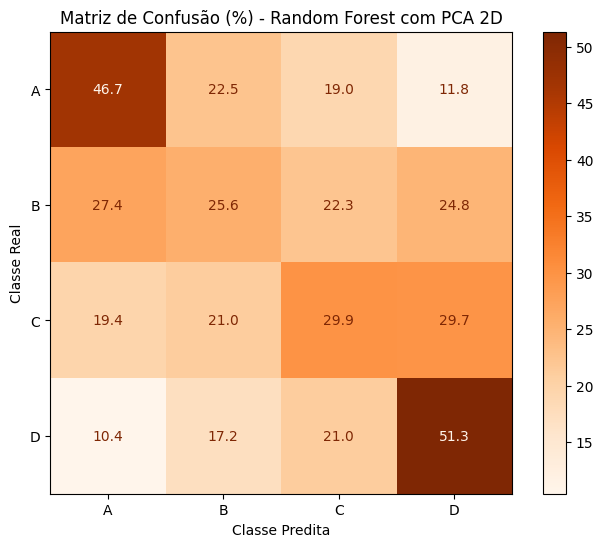

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

# Suprimindo avisos do Sklearn
warnings.filterwarnings('ignore')

# 1. Preparando X e y a partir do df_pca (Usando apenas PC1 e PC2)
X_pca_rf = df_pca[['PC1', 'PC2']]
y_pca_rf = df_pca['Classe Real']

# 2. Transformando a variável alvo (A/B/C/D) -> (0/1/2/3)
encoder_class_pca_rf = LabelEncoder()
y_encoded_pca_rf = encoder_class_pca_rf.fit_transform(y_pca_rf)

# 3. Dividindo em Treino e Teste
X_train_pca_rf, X_test_pca_rf, y_train_pca_rf, y_test_pca_rf = train_test_split(
    X_pca_rf, y_encoded_pca_rf, test_size=0.2, random_state=42, stratify=y_encoded_pca_rf
)

# Nota: Omitimos o StandardScaler pois o Random Forest é imune à escala dos dados.

# 4. Instanciando e Treinando o Modelo (mantendo as suas 130 árvores)
rf_pca_model = RandomForestClassifier(n_estimators=130, max_depth=25, random_state=42)
rf_pca_model.fit(X_train_pca_rf, y_train_pca_rf)

# 5. Prevendo classes e probabilidades
y_pred_pca_rf = rf_pca_model.predict(X_test_pca_rf)
y_prob_pca_rf = rf_pca_model.predict_proba(X_test_pca_rf)

# 6. Calculando todas as Métricas
acuracia_pca_rf = accuracy_score(y_test_pca_rf, y_pred_pca_rf)
precisao_pca_rf = precision_score(y_test_pca_rf, y_pred_pca_rf, average='macro')
recall_pca_rf = recall_score(y_test_pca_rf, y_pred_pca_rf, average='macro')
f1_pca_rf = f1_score(y_test_pca_rf, y_pred_pca_rf, average='macro')
roc_auc_pca_rf = roc_auc_score(y_test_pca_rf, y_prob_pca_rf, multi_class='ovr')

# Imprimindo os resultados formatados
print("Resultados: Random Forest com PCA (2D)")
print(f"Acurácia: {acuracia_pca_rf:.4f}")
print(f"Precisão: {precisao_pca_rf:.4f}")
print(f"Recall:   {recall_pca_rf:.4f}")
print(f"F1-score: {f1_pca_rf:.4f}")
print(f"ROC-AUC:  {roc_auc_pca_rf:.4f}")

# 7. Matriz de Confusão em Porcentagem
# normalize='true' calcula a % em relação ao total de cada linha (Classe Real)
cm_percent_pca_rf = confusion_matrix(y_test_pca_rf, y_pred_pca_rf, normalize='true') * 100

# Plotando a Matriz
disp_pca_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent_pca_rf,
    display_labels=encoder_class_pca_rf.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
# values_format='.1f' exibe em % com 1 casa decimal
disp_pca_rf.plot(cmap='Oranges', ax=ax, values_format='.1f')

plt.title('Matriz de Confusão (%) - Random Forest com PCA 2D')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.show()

## 4.5 XGBoost com PCA

Resultados: XGBoost com PCA (2D)
Acurácia: 0.4046
Precisão: 0.3832
Recall:   0.4045
F1-score: 0.3785
ROC-AUC:  0.6756
------------------------------------------


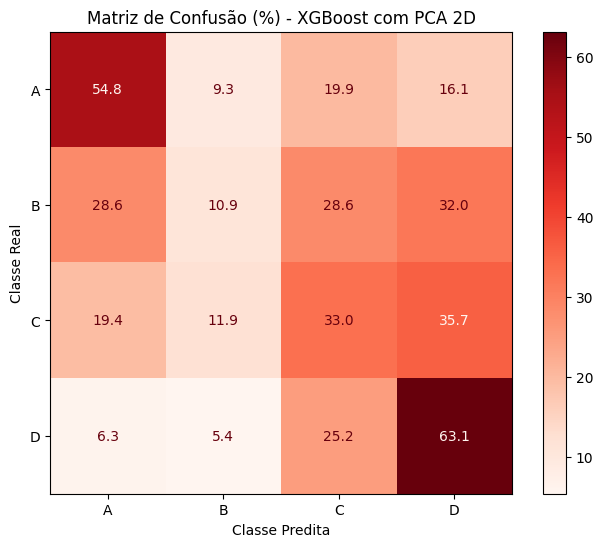

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

# Suprimindo avisos do Sklearn
warnings.filterwarnings('ignore')

# 1. Preparando X e y a partir do df_pca (Usando apenas PC1 e PC2)
X_pca_xgb = df_pca[['PC1', 'PC2']]
y_pca_xgb = df_pca['Classe Real']

# 2. Transformando a variável alvo (A/B/C/D) -> (0/1/2/3)
# O XGBoost exige estritamente que as classes sejam numéricas começando em 0.
encoder_class_pca_xgb = LabelEncoder()
y_encoded_pca_xgb = encoder_class_pca_xgb.fit_transform(y_pca_xgb)

# 3. Dividindo em Treino e Teste
X_train_pca_xgb, X_test_pca_xgb, y_train_pca_xgb, y_test_pca_xgb = train_test_split(
    X_pca_xgb, y_encoded_pca_xgb, test_size=0.2, random_state=42, stratify=y_encoded_pca_xgb
)

# 4. Instanciando e Treinando o Modelo
xgb_pca_model = xgb.XGBClassifier(
    n_estimators=90,
    max_depth=5,
    learning_rate=0.1,
    objective='multi:softprob',
    random_state=42
)
xgb_pca_model.fit(X_train_pca_xgb, y_train_pca_xgb)

# 5. Prevendo classes e probabilidades
y_pred_pca_xgb = xgb_pca_model.predict(X_test_pca_xgb)
y_prob_pca_xgb = xgb_pca_model.predict_proba(X_test_pca_xgb)

# 6. Calculando todas as Métricas
acuracia_pca_xgb = accuracy_score(y_test_pca_xgb, y_pred_pca_xgb)
precisao_pca_xgb = precision_score(y_test_pca_xgb, y_pred_pca_xgb, average='macro')
recall_pca_xgb = recall_score(y_test_pca_xgb, y_pred_pca_xgb, average='macro')
f1_pca_xgb = f1_score(y_test_pca_xgb, y_pred_pca_xgb, average='macro')
roc_auc_pca_xgb = roc_auc_score(y_test_pca_xgb, y_prob_pca_xgb, multi_class='ovr')

# Imprimindo os resultados formatados
print("Resultados: XGBoost com PCA (2D)")
print(f"Acurácia: {acuracia_pca_xgb:.4f}")
print(f"Precisão: {precisao_pca_xgb:.4f}")
print(f"Recall:   {recall_pca_xgb:.4f}")
print(f"F1-score: {f1_pca_xgb:.4f}")
print(f"ROC-AUC:  {roc_auc_pca_xgb:.4f}")
print("-" * 42)

# 7. Matriz de Confusão em Porcentagem
# normalize='true' calcula a % em relação ao total de cada linha (Classe Real)
cm_percent_pca_xgb = confusion_matrix(y_test_pca_xgb, y_pred_pca_xgb, normalize='true') * 100

# Plotando a Matriz
disp_pca_xgb = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent_pca_xgb,
    display_labels=encoder_class_pca_xgb.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
# values_format='.1f' exibe em % com 1 casa decimal
disp_pca_xgb.plot(cmap='Reds', ax=ax, values_format='.1f')

plt.title('Matriz de Confusão (%) - XGBoost com PCA 2D')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.show()

## 4.6 SVM (SVC) com PCA

Resultados: SVM (SVC) com PCA (2D)
Acurácia: 0.4061
Precisão: 0.3823
Recall:   0.4060
F1-score: 0.3817
ROC-AUC:  0.6730
------------------------------------------


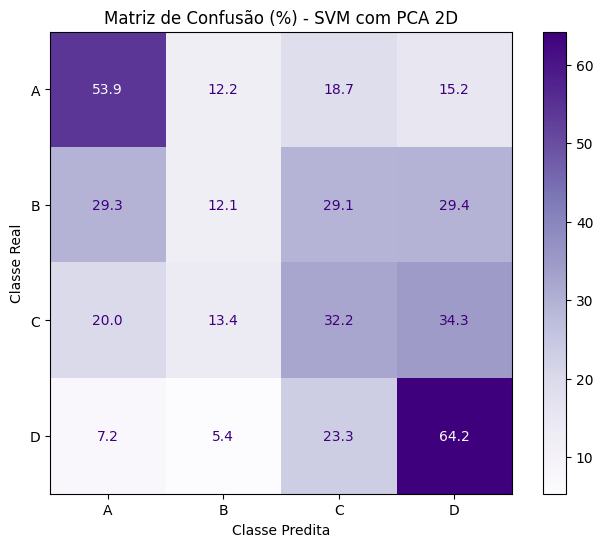

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

# Suprimindo avisos do Sklearn
warnings.filterwarnings('ignore')

# 1. Preparando X e y a partir do df_pca (Usando apenas PC1 e PC2)
X_pca_svm = df_pca[['PC1', 'PC2']]
y_pca_svm = df_pca['Classe Real']

# 2. Transformando a variável alvo (A/B/C/D) -> (0/1/2/3)
encoder_class_pca_svm = LabelEncoder()
y_encoded_pca_svm = encoder_class_pca_svm.fit_transform(y_pca_svm)

# 3. Dividindo em Treino e Teste
X_train_pca_svm, X_test_pca_svm, y_train_pca_svm, y_test_pca_svm = train_test_split(
    X_pca_svm, y_encoded_pca_svm, test_size=0.2, random_state=42, stratify=y_encoded_pca_svm
)

# 4. O RETORNO DO ESCALONAMENTO (Essencial para as margens geométricas do SVM)
scaler_pca_svm = StandardScaler()
X_train_svm_scaled = scaler_pca_svm.fit_transform(X_train_pca_svm)
X_test_svm_scaled = scaler_pca_svm.transform(X_test_pca_svm)

# 5. Instanciando o modelo SVC com os seus hiperparâmetros originais
# kernel='rbf': Cria curvas não-lineares projetando dados para dimensões superiores
# probability=True: Permite calcular probabilidades para extrair o ROC-AUC
svm_pca_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)

# 6. Treinando o modelo
svm_pca_model.fit(X_train_svm_scaled, y_train_pca_svm)

# 7. Fazendo as previsões
y_pred_pca_svm = svm_pca_model.predict(X_test_svm_scaled)
y_prob_pca_svm = svm_pca_model.predict_proba(X_test_svm_scaled)

# 8. Calculando as métricas obrigatórias
acuracia_pca_svm = accuracy_score(y_test_pca_svm, y_pred_pca_svm)
precisao_pca_svm = precision_score(y_test_pca_svm, y_pred_pca_svm, average='macro')
recall_pca_svm = recall_score(y_test_pca_svm, y_pred_pca_svm, average='macro')
f1_pca_svm = f1_score(y_test_pca_svm, y_pred_pca_svm, average='macro')
roc_auc_pca_svm = roc_auc_score(y_test_pca_svm, y_prob_pca_svm, multi_class='ovr')

# Imprimindo os resultados formatados
print("Resultados: SVM (SVC) com PCA (2D)")
print(f"Acurácia: {acuracia_pca_svm:.4f}")
print(f"Precisão: {precisao_pca_svm:.4f}")
print(f"Recall:   {recall_pca_svm:.4f}")
print(f"F1-score: {f1_pca_svm:.4f}")
print(f"ROC-AUC:  {roc_auc_pca_svm:.4f}")
print("-" * 42)

# 9. Plotando a Matriz de Confusão em Porcentagem
# normalize='true' calcula a % em relação ao total de cada linha (Classe Real)
cm_percent_pca_svm = confusion_matrix(y_test_pca_svm, y_pred_pca_svm, normalize='true') * 100

disp_pca_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent_pca_svm,
    display_labels=encoder_class_pca_svm.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
# values_format='.1f' exibe em % com 1 casa decimal
disp_pca_svm.plot(cmap='Purples', ax=ax, values_format='.1f')

plt.title('Matriz de Confusão (%) - SVM com PCA 2D')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.show()

Resultados: SVM (SVC) com PCA (2D)
Acurácia: 0.4061
Precisão: 0.3823
Recall:   0.4060
F1-score: 0.3817
ROC-AUC:  0.6730
------------------------------------------


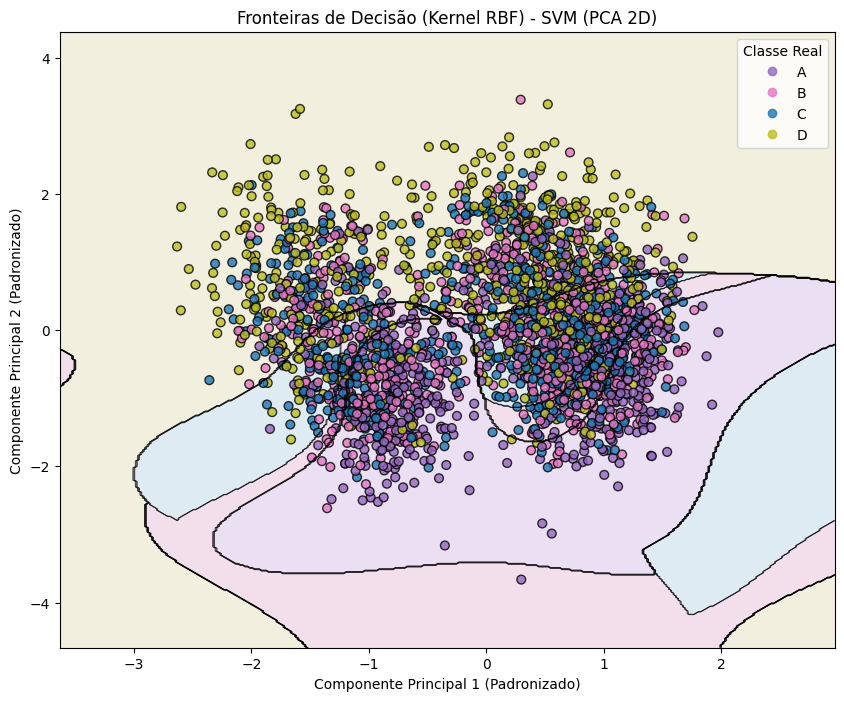

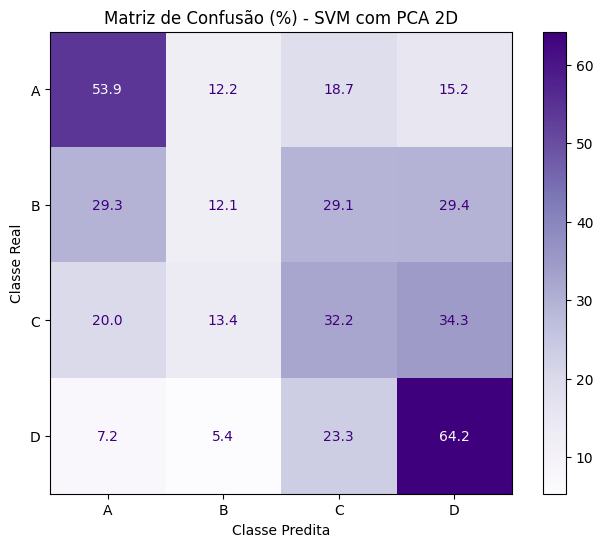

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from matplotlib.colors import ListedColormap

# Suprimindo avisos do Sklearn
warnings.filterwarnings('ignore')

# 1. Preparando X e y a partir do df_pca (Usando apenas PC1 e PC2)
X_pca_svm = df_pca[['PC1', 'PC2']]
y_pca_svm = df_pca['Classe Real']

# 2. Transformando a variável alvo (A/B/C/D) -> (0/1/2/3)
encoder_class_pca_svm = LabelEncoder()
y_encoded_pca_svm = encoder_class_pca_svm.fit_transform(y_pca_svm)

# 3. Dividindo em Treino e Teste
X_train_pca_svm, X_test_pca_svm, y_train_pca_svm, y_test_pca_svm = train_test_split(
    X_pca_svm, y_encoded_pca_svm, test_size=0.2, random_state=42, stratify=y_encoded_pca_svm
)

# 4. O RETORNO DO ESCALONAMENTO (Essencial para as margens geométricas do SVM)
scaler_pca_svm = StandardScaler()
X_train_svm_scaled = scaler_pca_svm.fit_transform(X_train_pca_svm)
X_test_svm_scaled = scaler_pca_svm.transform(X_test_pca_svm)

# 5. Instanciando o modelo SVC com os seus hiperparâmetros originais
svm_pca_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)

# 6. Treinando o modelo
svm_pca_model.fit(X_train_svm_scaled, y_train_pca_svm)

# 7. Fazendo as previsões
y_pred_pca_svm = svm_pca_model.predict(X_test_svm_scaled)
y_prob_pca_svm = svm_pca_model.predict_proba(X_test_svm_scaled)

# 8. Calculando as métricas obrigatórias
acuracia_pca_svm = accuracy_score(y_test_pca_svm, y_pred_pca_svm)
precisao_pca_svm = precision_score(y_test_pca_svm, y_pred_pca_svm, average='macro')
recall_pca_svm = recall_score(y_test_pca_svm, y_pred_pca_svm, average='macro')
f1_pca_svm = f1_score(y_test_pca_svm, y_pred_pca_svm, average='macro')
roc_auc_pca_svm = roc_auc_score(y_test_pca_svm, y_prob_pca_svm, multi_class='ovr')

# Imprimindo os resultados formatados
print("Resultados: SVM (SVC) com PCA (2D)")
print(f"Acurácia: {acuracia_pca_svm:.4f}")
print(f"Precisão: {precisao_pca_svm:.4f}")
print(f"Recall:   {recall_pca_svm:.4f}")
print(f"F1-score: {f1_pca_svm:.4f}")
print(f"ROC-AUC:  {roc_auc_pca_svm:.4f}")
print("-" * 42)

# =====================================================================
# NOVO BLOCO: PLOTANDO AS FRONTEIRAS DE DECISÃO (RBF)
# =====================================================================
plt.figure(figsize=(10, 8))

# Criando uma malha de pontos (grid)
x_min, x_max = X_test_svm_scaled[:, 0].min() - 1, X_test_svm_scaled[:, 0].max() + 1
y_min, y_max = X_test_svm_scaled[:, 1].min() - 1, X_test_svm_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Prevendo a classe para cada ponto na malha
Z = svm_pca_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Desenhando as zonas de cada classe (tons pastéis de roxo, rosa, etc para combinar com o tema)
cmap_light = ListedColormap(['#e6d8f0', '#f0d8e6', '#d8e6f0', '#f0ebd8'])
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

# Desenhando as linhas exatas de separação (As "Estradas")
plt.contour(xx, yy, Z, colors='k', linewidths=0.5)

# Adicionando os pontos reais do conjunto de teste por cima
scatter = plt.scatter(X_test_svm_scaled[:, 0], X_test_svm_scaled[:, 1],
                      c=y_test_pca_svm, cmap=ListedColormap(['#9467bd', '#e377c2', '#1f77b4', '#bcbd22']),
                      edgecolor='k', s=40, alpha=0.8)

plt.title('Fronteiras de Decisão (Kernel RBF) - SVM (PCA 2D)')
plt.xlabel('Componente Principal 1 (Padronizado)')
plt.ylabel('Componente Principal 2 (Padronizado)')

# Legenda baseada nas classes originais
classes_nomes = encoder_class_pca_svm.classes_
plt.legend(handles=scatter.legend_elements()[0], labels=list(classes_nomes), title="Classe Real")
plt.show()

# =====================================================================
# 9. Matriz de Confusão em Porcentagem
# =====================================================================
cm_percent_pca_svm = confusion_matrix(y_test_pca_svm, y_pred_pca_svm, normalize='true') * 100

disp_pca_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent_pca_svm,
    display_labels=encoder_class_pca_svm.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp_pca_svm.plot(cmap='Purples', ax=ax, values_format='.1f')

plt.title('Matriz de Confusão (%) - SVM com PCA 2D')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.show()

## 4.7 Rede Neural (MLP) com PCA

Resultados: Rede Neural (MLP) com PCA (2D)
Acurácia: 0.4196
Precisão: 0.3903
Recall:   0.4194
F1-score: 0.3908
ROC-AUC:  0.6853
--------------------------------------------------


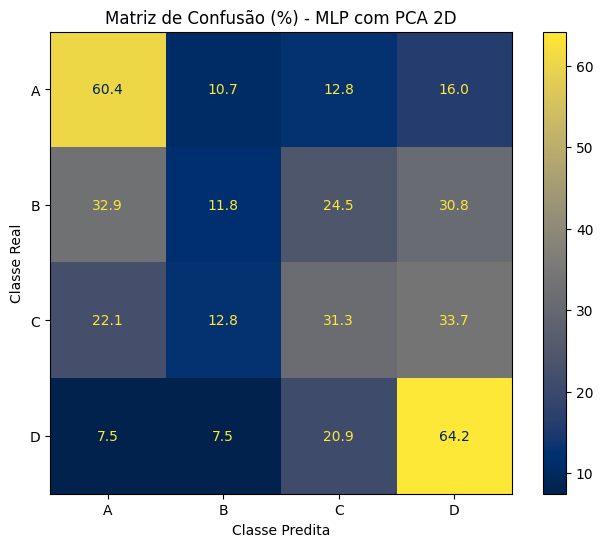

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

# Suprimindo avisos do Sklearn
warnings.filterwarnings('ignore')

# 1. Preparando X e y a partir do df_pca (Usando apenas PC1 e PC2)
X_pca_mlp = df_pca[['PC1', 'PC2']]
y_pca_mlp = df_pca['Classe Real']

# 2. Transformando a variável alvo (A/B/C/D) -> (0/1/2/3)
encoder_class_pca_mlp = LabelEncoder()
y_encoded_pca_mlp = encoder_class_pca_mlp.fit_transform(y_pca_mlp)

# 3. Dividindo em Treino e Teste
X_train_pca_mlp, X_test_pca_mlp, y_train_pca_mlp, y_test_pca_mlp = train_test_split(
    X_pca_mlp, y_encoded_pca_mlp, test_size=0.2, random_state=42, stratify=y_encoded_pca_mlp
)

# 4. OBRIGATÓRIO: Escalonamento dos dados para a Rede Neural
scaler_pca_mlp = StandardScaler()
X_train_mlp_scaled = scaler_pca_mlp.fit_transform(X_train_pca_mlp)
X_test_mlp_scaled = scaler_pca_mlp.transform(X_test_pca_mlp)

# 5. Instanciando o modelo MLP com os seus hiperparâmetros originais
# hidden_layer_sizes=(100, 50): 2 camadas ocultas (100 e 50 neurônios)
# max_iter=500: Permite até 500 épocas de treinamento
mlp_pca_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)

# 6. Treinando o modelo
mlp_pca_model.fit(X_train_mlp_scaled, y_train_pca_mlp)

# 7. Fazendo as previsões
y_pred_pca_mlp = mlp_pca_model.predict(X_test_mlp_scaled)
y_prob_pca_mlp = mlp_pca_model.predict_proba(X_test_mlp_scaled)

# 8. Calculando as métricas obrigatórias
acuracia_pca_mlp = accuracy_score(y_test_pca_mlp, y_pred_pca_mlp)
precisao_pca_mlp = precision_score(y_test_pca_mlp, y_pred_pca_mlp, average='macro')
recall_pca_mlp = recall_score(y_test_pca_mlp, y_pred_pca_mlp, average='macro')
f1_pca_mlp = f1_score(y_test_pca_mlp, y_pred_pca_mlp, average='macro')
roc_auc_pca_mlp = roc_auc_score(y_test_pca_mlp, y_prob_pca_mlp, multi_class='ovr')

# Imprimindo os resultados formatados
print("Resultados: Rede Neural (MLP) com PCA (2D)")
print(f"Acurácia: {acuracia_pca_mlp:.4f}")
print(f"Precisão: {precisao_pca_mlp:.4f}")
print(f"Recall:   {recall_pca_mlp:.4f}")
print(f"F1-score: {f1_pca_mlp:.4f}")
print(f"ROC-AUC:  {roc_auc_pca_mlp:.4f}")
print("-" * 50)

# 9. Plotando a Matriz de Confusão em Porcentagem
# normalize='true' calcula a % em relação ao total de cada linha (Classe Real)
cm_percent_pca_mlp = confusion_matrix(y_test_pca_mlp, y_pred_pca_mlp, normalize='true') * 100

disp_pca_mlp = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent_pca_mlp,
    display_labels=encoder_class_pca_mlp.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
# values_format='.1f' exibe em % com 1 casa decimal
disp_pca_mlp.plot(cmap='cividis', ax=ax, values_format='.1f')

plt.title('Matriz de Confusão (%) - MLP com PCA 2D')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.show()

# 5. Modelos Não Supervisionados

## 5.1 K-Means — Escolha do K (Cotovelo + Silhouette)

Calculando Inércia e Silhouette para diferentes valores de K... (Isso pode levar um minutinho)


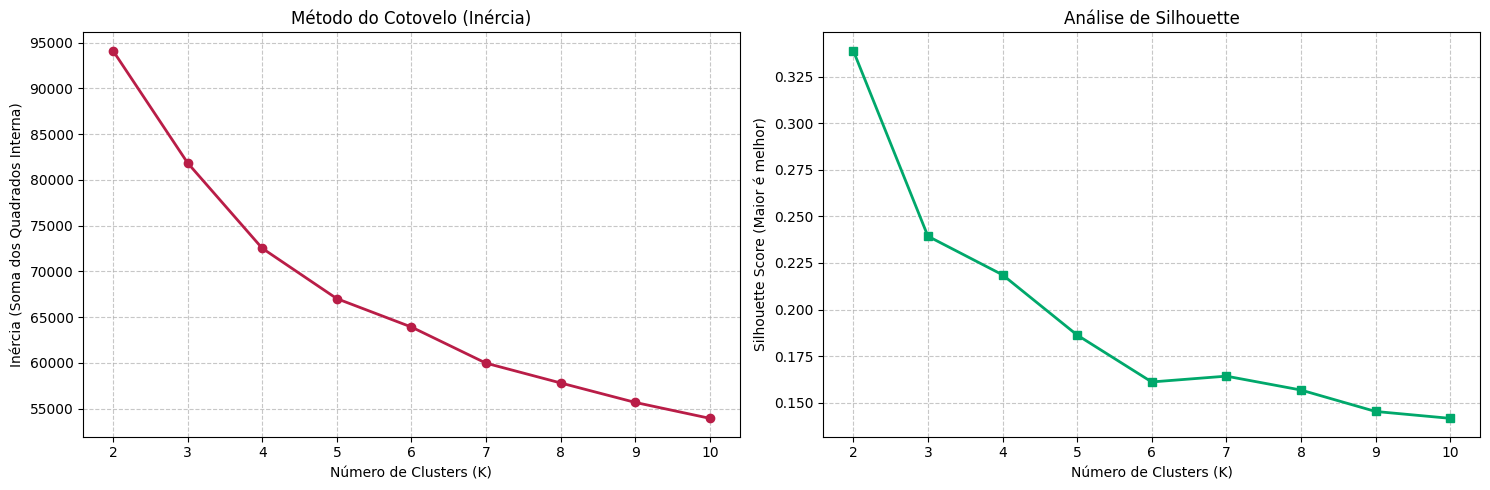

In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inercia = []
silhouette_scores = []
K_range = range(2, 11) # Testando a divisão de 2 até 10 grupos

print("Calculando Inércia e Silhouette para diferentes valores de K... (Isso pode levar um minutinho)")

for k in K_range:
    # n_init=10 faz o algoritmo rodar 10 vezes internamente e escolher a melhor inicialização
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca_scaled)

    # Extraindo a Inércia
    inercia.append(kmeans.inertia_)

    # Extraindo o Silhouette Score
    sil_score = silhouette_score(X_pca_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)

# --- Construindo o painel de gráficos ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Método do Cotovelo
ax1.plot(K_range, inercia, marker='o', color='#b91d47', linewidth=2)
ax1.set_title('Método do Cotovelo (Inércia)')
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inércia (Soma dos Quadrados Interna)')
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Silhouette Score
ax2.plot(K_range, silhouette_scores, marker='s', color='#00a86b', linewidth=2)
ax2.set_title('Análise de Silhouette')
ax2.set_xlabel('Número de Clusters (K)')
ax2.set_ylabel('Silhouette Score (Maior é melhor)')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 5.2 K-Means — Modelo Final

Resultados: K-Means (K=6)
Inércia: 63907.43 (Compactação dos grupos)
Silhouette: 0.1611 (Pertencimento / 'Estou no grupo certo?')
Calinski-Harabasz (CH): 3494.70 (Separação global)
Davies-Bouldin (DB): 1.7890 (Risco de sobreposição)


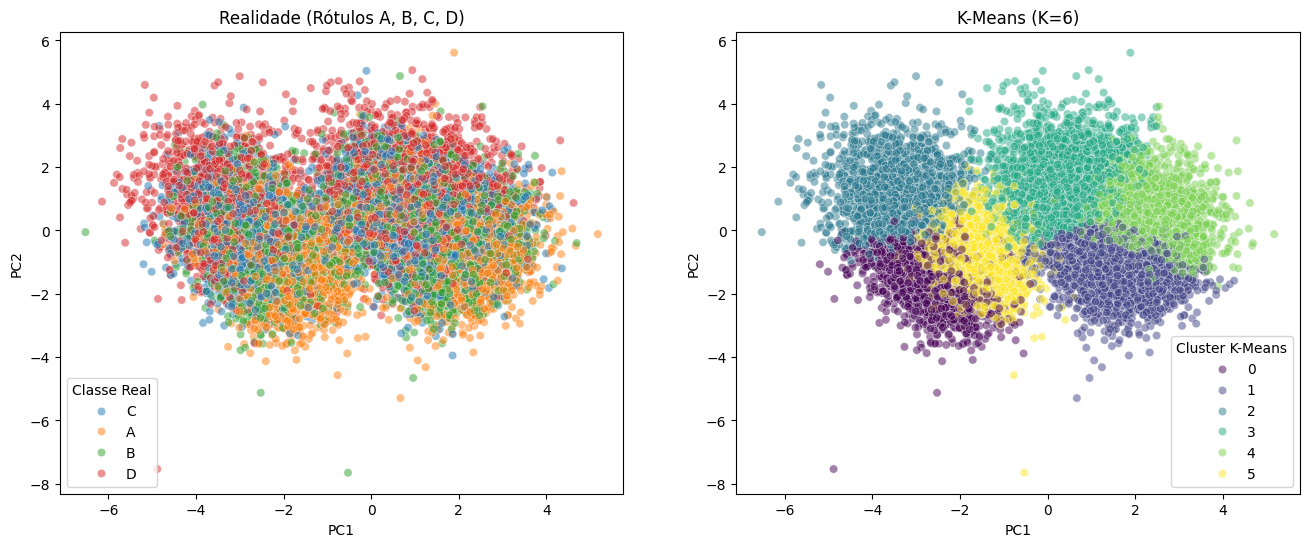

In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# 1. Instanciando e treinando o K-Means forçando 4 grupos (para comparar com A,B,C,D)
kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_pca_scaled)

# 2. Calculando as 4 Métricas Obrigatórias exigidas no slide 14
inercia_kmeans = kmeans_final.inertia_
sil_kmeans = silhouette_score(X_pca_scaled, labels_kmeans)
ch_kmeans = calinski_harabasz_score(X_pca_scaled, labels_kmeans)
db_kmeans = davies_bouldin_score(X_pca_scaled, labels_kmeans)

# Imprimindo os resultados para a Tabela de Agrupamento
print("Resultados: K-Means (K=6)")
print(f"Inércia: {inercia_kmeans:.2f} (Compactação dos grupos)")
print(f"Silhouette: {sil_kmeans:.4f} (Pertencimento / 'Estou no grupo certo?')")
print(f"Calinski-Harabasz (CH): {ch_kmeans:.2f} (Separação global)")
print(f"Davies-Bouldin (DB): {db_kmeans:.4f} (Risco de sobreposição)")

# 3. Visualização: O que o K-Means achou vs O que é Real
# Adicionando os rótulos do K-Means ao nosso DataFrame do PCA
df_pca['Cluster K-Means'] = labels_kmeans

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: A realidade (Classes A, B, C, D)
sns.scatterplot(x='PC1', y='PC2', hue='Classe Real', data=df_pca,
                palette=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.5, ax=ax1)
ax1.set_title('Realidade (Rótulos A, B, C, D)')

# Gráfico 2: A visão do K-Means (Clusters 0, 1, 2, 3)
sns.scatterplot(x='PC1', y='PC2', hue='Cluster K-Means', data=df_pca,
                palette='viridis', alpha=0.5, ax=ax2)
ax2.set_title('K-Means (K=6)')

plt.show()

## 5.3 DBSCAN — Busca de Hiperparâmetros (eps)

In [44]:
from sklearn.cluster import DBSCAN

print("Testando diferentes raios de alcance (eps) para 11 Dimensões...\n")

# Vamos testar valores de Epsilon de 1.0 até 5.0
valores_eps = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]

for eps_teste in valores_eps:
    dbscan_teste = DBSCAN(eps=eps_teste, min_samples=10)
    labels_teste = dbscan_teste.fit_predict(X_pca_scaled)

    n_clusters = len(set(labels_teste)) - (1 if -1 in labels_teste else 0)
    n_ruido = list(labels_teste).count(-1)

    print(f"EPS: {eps_teste:.1f} -> Clusters encontrados: {n_clusters} | Atletas como Ruído: {n_ruido}")

Testando diferentes raios de alcance (eps) para 11 Dimensões...

EPS: 1.0 -> Clusters encontrados: 7 | Atletas como Ruído: 8149
EPS: 1.5 -> Clusters encontrados: 2 | Atletas como Ruído: 783
EPS: 2.0 -> Clusters encontrados: 2 | Atletas como Ruído: 138
EPS: 2.5 -> Clusters encontrados: 1 | Atletas como Ruído: 43
EPS: 3.0 -> Clusters encontrados: 1 | Atletas como Ruído: 15
EPS: 3.5 -> Clusters encontrados: 1 | Atletas como Ruído: 10
EPS: 4.0 -> Clusters encontrados: 1 | Atletas como Ruído: 7
EPS: 5.0 -> Clusters encontrados: 1 | Atletas como Ruído: 5


## 5.4 DBSCAN — Modelo Final

--- Resultados Finais: DBSCAN (eps=2.0, min_samples=10) ---
Clusters encontrados: 2
Atletas classificados como Ruído: 138

Silhouette: 0.3354
Calinski-Harabasz (CH): 3734.23
Davies-Bouldin (DB): 2.7388


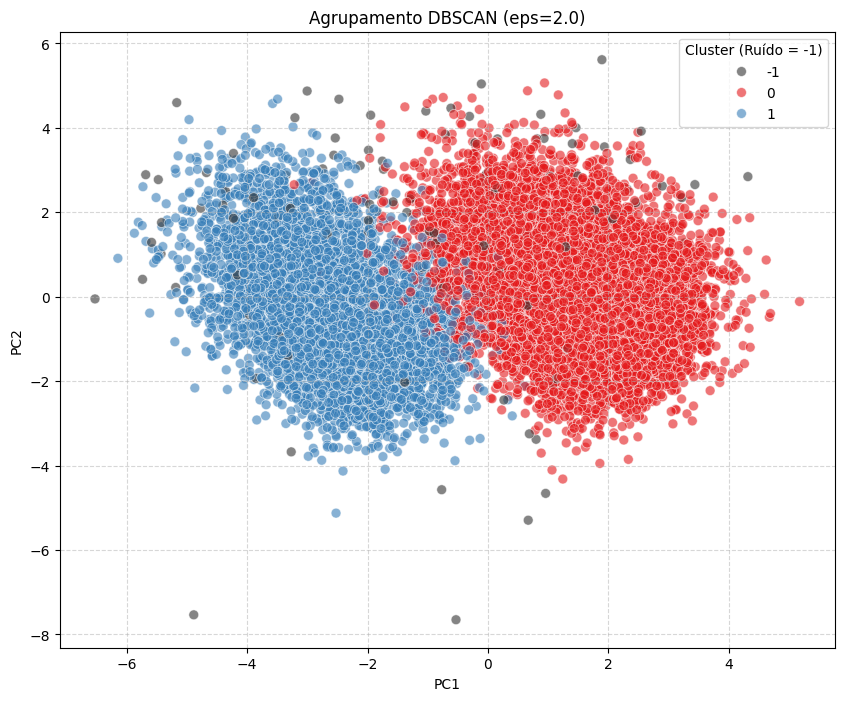

In [45]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Treinando o DBSCAN com o nosso "Ponto de Ouro"
dbscan_final = DBSCAN(eps=2.0, min_samples=10)
labels_dbscan_final = dbscan_final.fit_predict(X_pca_scaled)

# 2. Imprimindo os Resultados para a Tabela
n_clusters_final = len(set(labels_dbscan_final)) - (1 if -1 in labels_dbscan_final else 0)
n_ruido_final = list(labels_dbscan_final).count(-1)

print("--- Resultados Finais: DBSCAN (eps=2.0, min_samples=10) ---")
print(f"Clusters encontrados: {n_clusters_final}")
print(f"Atletas classificados como Ruído: {n_ruido_final}\n")

# Calculando as métricas (agora vai funcionar porque temos 2 clusters)
sil_dbscan = silhouette_score(X_pca_scaled, labels_dbscan_final)
ch_dbscan = calinski_harabasz_score(X_pca_scaled, labels_dbscan_final)
db_dbscan = davies_bouldin_score(X_pca_scaled, labels_dbscan_final)

print(f"Silhouette: {sil_dbscan:.4f}")
print(f"Calinski-Harabasz (CH): {ch_dbscan:.2f}")
print(f"Davies-Bouldin (DB): {db_dbscan:.4f}")

# 3. A Visualização Final
df_pca['Cluster DBSCAN Final'] = labels_dbscan_final

plt.figure(figsize=(10, 8))

# Criando paleta: Ruído (-1) em preto, Clusters em cores distintas
cores = sns.color_palette("Set1", n_clusters_final)
if -1 in labels_dbscan_final:
    cores = [(0.2, 0.2, 0.2)] + cores # Adiciona cinza escuro no início da paleta

sns.scatterplot(x='PC1', y='PC2', hue='Cluster DBSCAN Final', data=df_pca,
                palette=cores, alpha=0.6, s=50)

plt.title('Agrupamento DBSCAN (eps=2.0)')
plt.legend(title='Cluster (Ruído = -1)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()